<a href="https://colab.research.google.com/github/yasirbinkasim/Data-Analysis-Visualisation-in-Panda/blob/main/Module_2_Data_Analysis_%26_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Exploratory Data Analysis(EDA)**

EDA is the process of understanding a dataset before building any machine learning models. It helps identify patterns, a relationships, missing values, outliers, aand anomalies

**Objectives**

1. Understand the structure of data
2. Find miising values
3. Detect outliers
4. Analyze distrubution
5. Find relationships between variables
6. Generate business insights

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving titanic.csv to titanic.csv
User uploaded file "titanic.csv" with length 3258 bytes


In [2]:
from google.colab import files

print("Please select 'titanic.csv' from your local machine to upload.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please select 'titanic.csv' from your local machine to upload.


Saving titanic.csv to titanic.csv
User uploaded file "titanic.csv" with length 3258 bytes


   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None
Shape: (418, 2)
Columns: Index(['PassengerId', 'Survived'], dtype='object')
       PassengerId    Survived
count   418.000000  418.000000
mean   1100.500000    0.366029
std     120.810458    0.482295
min     892.000000    0.000000
25%     996.250000    0.000000
50%    1100.500000    0.000000
75%    1204.750000    1.000000
max    1309.000000    1.000000
PassengerId    0
Survived       0
dtype: int64
Duplicates: 0
             PassengerId  Survived
PassengerId      1.00000  -0.05015
Survived        -0.05015   1.00000
Survived
0    265
1   

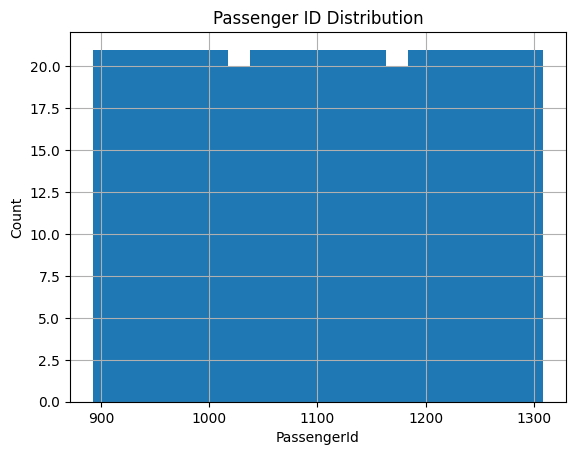

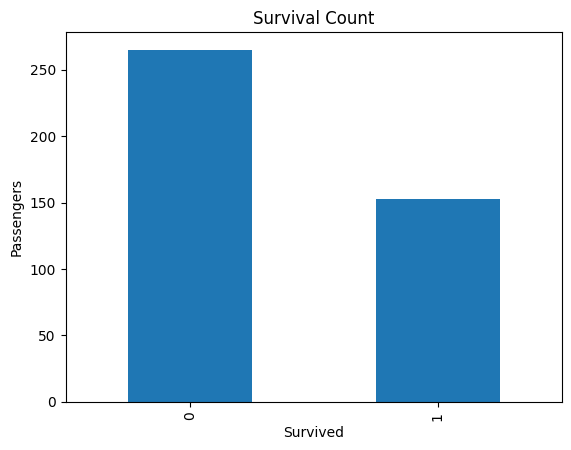

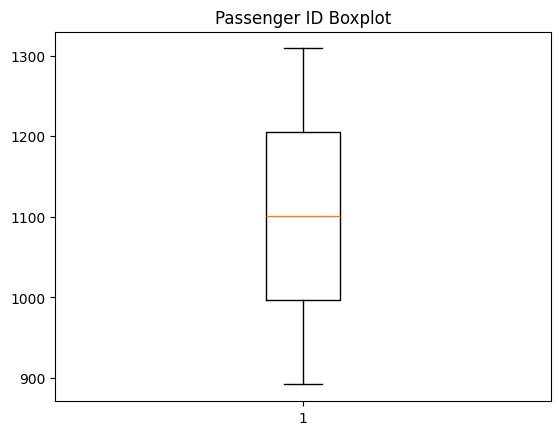

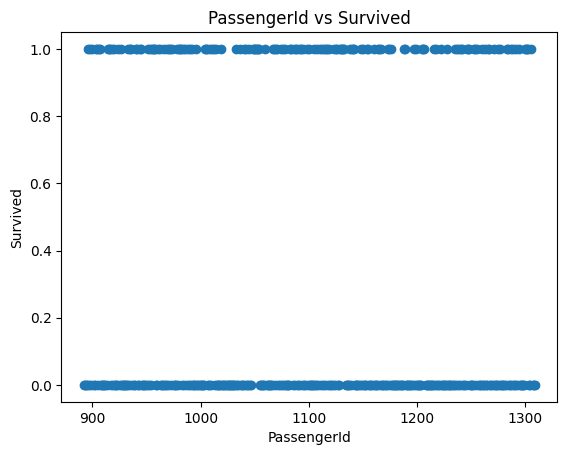

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("titanic.csv")

# First 5 rows
print(df.head())

# Dataset Information
print(df.info())

# Shape
print("Shape:", df.shape)

# Columns
print("Columns:", df.columns)

# Statistical Summary
print(df.describe())

# Missing Values
print(df.isnull().sum())

# Duplicate Rows
print("Duplicates:", df.duplicated().sum())

# Correlation
print(df.corr())

# Value Counts
print(df["Survived"].value_counts())

# Histogram
df["PassengerId"].hist(bins=20)
plt.title("Passenger ID Distribution")
plt.xlabel("PassengerId")
plt.ylabel("Count")
plt.show()

# Bar Chart
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Passengers")
plt.show()

# Box Plot
plt.boxplot(df["PassengerId"])
plt.title("Passenger ID Boxplot")
plt.show()

# Scatter Plot
plt.scatter(df["PassengerId"], df["Survived"])
plt.xlabel("PassengerId")
plt.ylabel("Survived")
plt.title("PassengerId vs Survived")
plt.show()

**Data Transformation**

Data transformation is the process of converting raw data into a cleaner and more suitable format for analysis or machine learning.

Common Transformations

1. Missing value treatment
2. Encoding
3. Scaling
4. Normalization
5. Standardization
6. Log Transformation
7. Binning
8. Data type conversion

In [ ]:
import pandas as pd
import numpy as np

# Import required libraries
# Pandas -> Data Manipulation
# NumPy -> Mathematical Operations

# ============================================
# Load Dataset
# ============================================

# Read CSV file into a DataFrame
# IMPORTANT: Update the path below to where your 'titanic.csv' is located.
# If it's in Google Drive, it might be something like '/content/drive/MyDrive/colab_data/titanic.csv'
df = pd.read_csv("titanic.csv")

print("Original Dataset")
print(df.head())

# ============================================
# 1. Check Missing Values
# Concept: Identify null (missing) values in each column.
# ============================================

print("\nMissing Values")
print(df.isnull().sum())

# ============================================
# 2. Fill Missing Values
# Concept: Replace missing values with suitable values.
# ============================================

# Fill missing PassengerId with Mean
df["PassengerId"] = df["PassengerId"].fillna(df["PassengerId"].mean())

# Fill missing Survived values with Mode
df["Survived"] = df["Survived"].fillna(df["Survived"].mode()[0])

print("\nAfter Filling Missing Values")
print(df.isnull().sum())

# ============================================
# 3. Remove Duplicate Rows
# Concept: Remove repeated records from the dataset.
# ============================================

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

# ============================================
# 4. Data Type Conversion
# Concept: Convert data into the required data type.
# ============================================

df["PassengerId"] = df["PassengerId"].astype(int)
df["Survived"] = df["Survived"].astype(int)

print("\nData Types")
print(df.dtypes)

# ============================================
# 5. Create Categorical Column
# Concept: Convert numeric values into meaningful categories.
# ============================================

df["Status"] = df["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})

print("\nStatus Column")
print(df.head())

# ============================================
# 6. Binning
# Concept: Divide continuous values into different groups.
# ============================================

df["PassengerGroup"] = pd.cut(
    df["PassengerId"],
    bins=4,
    labels=["Group A", "Group B", "Group C", "Group D"]
)

print("\nPassenger Groups")
print(df.head())

# ============================================
# 7. Standardization (Z-Score)
# Concept: Scale data with Mean = 0 and Standard Deviation = 1.
# ============================================

df["PassengerId_Standard"] = (
    df["PassengerId"] - df["PassengerId"].mean()
) / df["PassengerId"].std()

# ============================================
# 8. Min-Max Normalization
# Concept: Scale values between 0 and 1.
# ============================================

df["PassengerId_Normalized"] = (
    df["PassengerId"] - df["PassengerId"].min()
) / (
    df["PassengerId"].max() - df["PassengerId"].min()
)

# ============================================
# 9. Log Transformation
# Concept: Reduce skewness by compressing large values.
# ============================================

df["PassengerId_Log"] = np.log1p(df["PassengerId"])

# ============================================
# 10. Square Root Transformation
# Concept: Reduce the impact of large values.
# ============================================

df["PassengerId_Sqrt"] = np.sqrt(df["PassengerId"])

# ============================================
# 11. Square Transformation
# Concept: Increase the effect of larger values.
# ============================================

df["PassengerId_Square"] = df["PassengerId"] ** 2

# ============================================
# 12. Rank Transformation
# Concept: Assign ranking based on the values.
# ============================================

df["PassengerId_Rank"] = df["PassengerId"].rank()

# ============================================
# Final Dataset
# ============================================

# Display transformed dataset
print("\nTransformed Dataset")
print(df.head())

# Display dataset information
print("\nDataset Information")
print(df.info())

# ============================================
# Save Dataset
# Concept: Export transformed dataset to a CSV file.
# ============================================

df.to_csv("transformed_titanic.csv", index=False)

print("\nTransformed dataset saved successfully.")

Original Dataset
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Missing Values
PassengerId    0
Survived       0
dtype: int64

After Filling Missing Values
PassengerId    0
Survived       0
dtype: int64

Duplicate Rows: 0
Shape After Removing Duplicates: (418, 2)

Data Types
PassengerId    int64
Survived       int64
dtype: object

Status Column
   PassengerId  Survived        Status
0          892         0  Not Survived
1          893         0  Not Survived
2          894         0  Not Survived
3          895         0  Not Survived
4          896         1      Survived

Passenger Groups
   PassengerId  Survived        Status PassengerGroup
0          892         0  Not Survived        Group A
1          893         0  Not Survived        Group A
2          894         0  Not Survived        Group A
3          895         0  Not Survived        Group A
4          896         1   

In [ ]:
# To list files in 'Colab Notebooks' (if you think it might be there):
!ls '/content/drive/MyDrive/Colab Notebooks'

# If it's in a different folder, please replace 'Another_Folder' with its name:
# !ls '/content/drive/MyDrive/Another_Folder'

ls: cannot access '/content/drive/MyDrive/Colab Notebooks': No such file or directory


**Feature Engineering Basics**

Feature engineering is the process of creating new useful features from existing data to improve the performance of machine learning models.

In [3]:
import pandas as pd

df = pd.read_csv("titanic.csv")

# Passenger Type
df["PassengerType"] = df["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})

# Even/Odd Passenger ID
df["PassengerID_Type"] = df["PassengerId"] % 2

# Passenger Category
df["PassengerCategory"] = pd.cut(
    df["PassengerId"],
    bins=4,
    labels=["A", "B", "C", "D"]
)

print(df.head())

   PassengerId  Survived PassengerType  PassengerID_Type PassengerCategory
0          892         0  Not Survived                 0                 A
1          893         0  Not Survived                 1                 A
2          894         0  Not Survived                 0                 A
3          895         0  Not Survived                 1                 A
4          896         1      Survived                 0                 A
